In [118]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)




In [119]:
df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\customer_segments_labeled.csv"
)

print(df.shape)

df.head()

(4312, 6)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,165,11,372.86,1,At Risk Customers
1,12347,3,2,1323.32,0,Regular Customers
2,12348,74,1,222.16,0,Regular Customers
3,12349,43,3,2671.14,0,Regular Customers
4,12351,11,1,300.93,0,Regular Customers


In [120]:
df["AverageOrderValue"] = (

    df["Monetary"]

    / df["Frequency"]
)

df["AverageOrderValue"] = (
    df["Monetary"] /
    df["Frequency"]
)

df["FrequencyScore"] = (
    df["Frequency"] /
    df["Frequency"].max()
)

df["MonetaryScore"] = (
    df["Monetary"] /
    df["Monetary"].max()
)

In [121]:
df["Churn"] = (
    df["Recency"] > 90
).astype(int)
df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,AverageOrderValue,FrequencyScore,MonetaryScore,Churn
0,12346,165,11,372.86,1,At Risk Customers,33.896364,0.053659,0.001068,1
1,12347,3,2,1323.32,0,Regular Customers,661.660000,0.009756,0.003790,0
2,12348,74,1,222.16,0,Regular Customers,222.160000,0.004878,0.000636,0
3,12349,43,3,2671.14,0,Regular Customers,890.380000,0.014634,0.007650,0
4,12351,11,1,300.93,0,Regular Customers,300.930000,0.004878,0.000862,0


In [122]:

print("\nChurn Distribution\n")

print(
    df["Churn"]
    .value_counts()
)

print("\nNormalized\n")

print(
    df["Churn"]
    .value_counts(
        normalize=True
    )
)



Churn Distribution

Churn
0    2877
1    1435
Name: count, dtype: int64

Normalized

Churn
0    0.667208
1    0.332792
Name: proportion, dtype: float64


In [123]:
from sklearn.model_selection import train_test_split

features = [

    "Frequency",

    "Monetary",

    "AverageOrderValue",

    "FrequencyScore",

    "MonetaryScore"
]

X = df[features]

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("\nTrain Shape:", X_train.shape)

print("Test Shape :", X_test.shape)


Train Shape: (3449, 5)
Test Shape : (863, 5)


In [124]:
model = LogisticRegression(
    max_iter=1000
)

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

scores = cross_val_score(

    model,

    X,

    y,

    cv=cv,

    scoring="roc_auc"
)

print(scores)

print(
    "Mean AUC:",
    scores.mean()
)

print(
    "Std:",
    scores.std()
)

[0.74653988 0.74087483 0.76434783 0.75791244 0.75060748]
Mean AUC: 0.7520564908094733
Std: 0.00828168121151078


In [125]:
model.fit(
    X_train,
    y_train
)

preds = model.predict(
    X_test
)

probs = model.predict_proba(
    X_test
)[:, 1]


logistic_probs = model.predict_proba(
    X_test
)[:, 1]

In [126]:
print("\nLogistic Regression Results\n")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)


Logistic Regression Results

Accuracy: 0.7219003476245655
Precision: 0.6035242290748899
Recall: 0.47735191637630664
F1: 0.5330739299610895
ROC-AUC: 0.7373481658923732



Confusion Matrix

[[486  90]
 [150 137]]


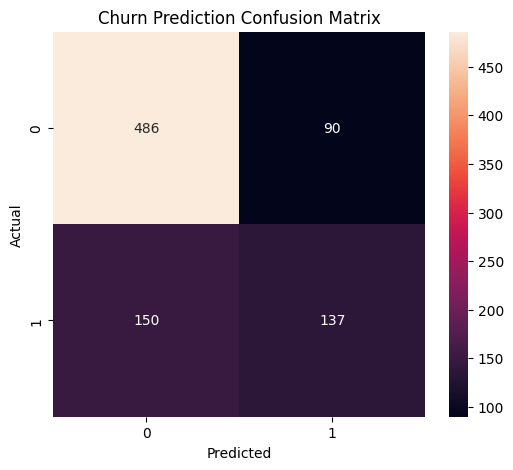

In [115]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    preds
)

print("\nConfusion Matrix\n")

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d"
)

plt.title(
    "Churn Prediction Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


In [116]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_[0]
})

importance_df = importance_df.sort_values(
    "Coefficient",
    ascending=False
)

importance_df

,Feature,Coefficient
1,Monetary,0.000068
2,AverageOrderValue,-0.000311
0,Frequency,-0.410434


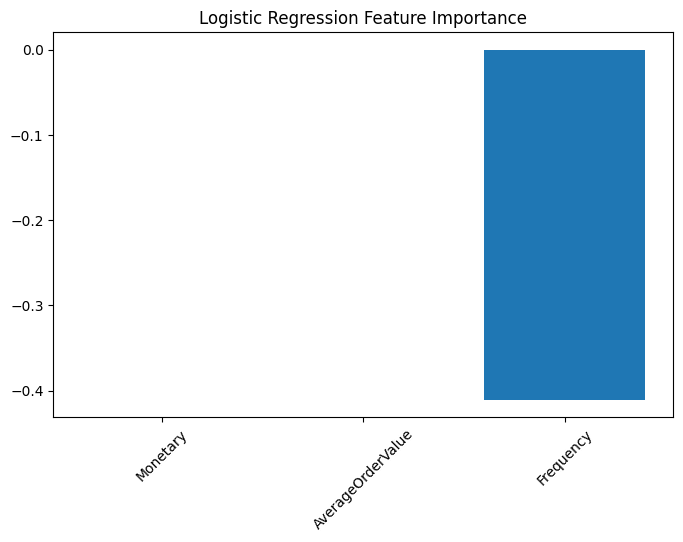

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Coefficient"]
)

plt.title(
    "Logistic Regression Feature Importance"
)

plt.xticks(rotation=45)

plt.show()

Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=8,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

preds = rf.predict(
    X_test
)

rf_probs = rf.predict_proba(
    X_test
)[:, 1]


In [74]:
# STRATIFIED 5-FOLD CV

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

scores = cross_val_score(

    rf,

    X,

    y,

    cv=cv,

    scoring="roc_auc"
)

print("\nRandom Forest CV")

print("Scores:", scores)

print("Mean AUC:", scores.mean())

print("Std AUC:", scores.std())




Random Forest CV
Scores: [0.73121431 0.73267518 0.7480715  0.74984093 0.73028935]
Mean AUC: 0.7384182562827182
Std AUC: 0.008655883374071426


In [75]:
# TRAIN

rf.fit(
    X_train,
    y_train
)

preds = rf.predict(
    X_test
)

probs = rf.predict_proba(
    X_test
)[:, 1]


In [76]:
rf_auc = roc_auc_score(
    y_test,
    probs
)

print(
    "ROC-AUC:",
    rf_auc
)

ROC-AUC: 0.7190857288037166


In [77]:

# =====================================================
# EVALUATION
# =====================================================

print("\nRandom Forest")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)


Random Forest
Accuracy: 0.6882966396292005
Precision: 0.5405405405405406
Recall: 0.4181184668989547
F1: 0.4715127701375246
ROC-AUC: 0.7190857288037166



Confusion Matrix

[[474 102]
 [167 120]]


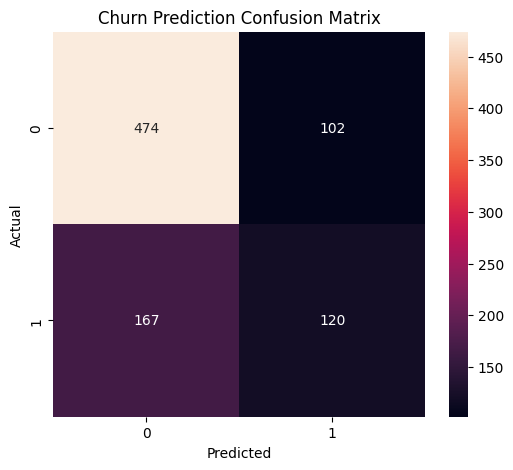

In [78]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    preds
)

print("\nConfusion Matrix\n")

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d"
)

plt.title(
    "Churn Prediction Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


In [79]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
4,MonetaryScore,0.258225
1,Monetary,0.241630
3,FrequencyScore,0.181227
2,AverageOrderValue,0.167675
0,Frequency,0.151244


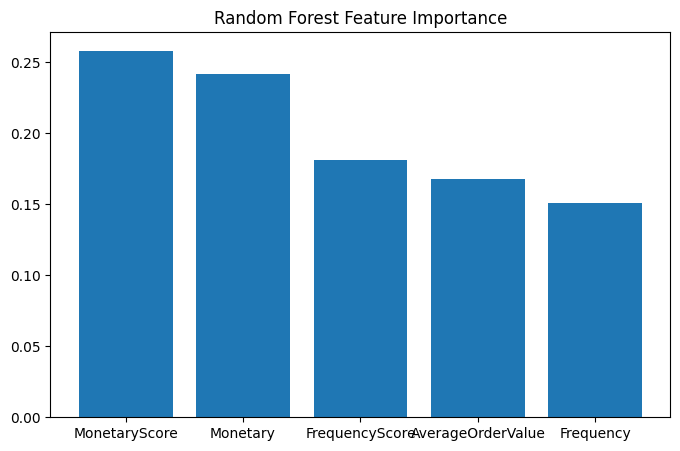

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    importance_df["Feature"],

    importance_df["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

XGBoost

In [81]:
from xgboost import XGBClassifier


xgb = XGBClassifier(

    n_estimators=300,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

In [82]:
# STRATIFIED 5-FOLD CV

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

scores = cross_val_score(

    xgb,

    X,

    y,

    cv=cv,

    scoring="roc_auc"
)

print("\nXGBoost CV")

print("Scores:", scores)

print("Mean AUC:", scores.mean())

print("Std AUC:", scores.std())



XGBoost CV
Scores: [0.72458442 0.72675002 0.73845478 0.74066051 0.72757158]
Mean AUC: 0.7316042624013196
Std AUC: 0.00660377839566521


In [83]:
# TRAIN

xgb.fit(
    X_train,
    y_train
)

preds = xgb.predict(
    X_test
)

probs = xgb.predict_proba(
    X_test
)[:, 1]


xgb_probs = xgb.predict_proba(
    X_test
)[:, 1]

In [84]:
xgb_auc = roc_auc_score(
    y_test,
    probs
)

print(
    "ROC-AUC:",
    xgb_auc
)

ROC-AUC: 0.7059771825396826


In [85]:

# EVALUATION

print("\nXGBoost")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)


XGBoost
Accuracy: 0.6767091541135574
Precision: 0.5166666666666667
Recall: 0.43205574912891986
F1: 0.47058823529411764
ROC-AUC: 0.7059771825396826



Confusion Matrix

[[460 116]
 [163 124]]


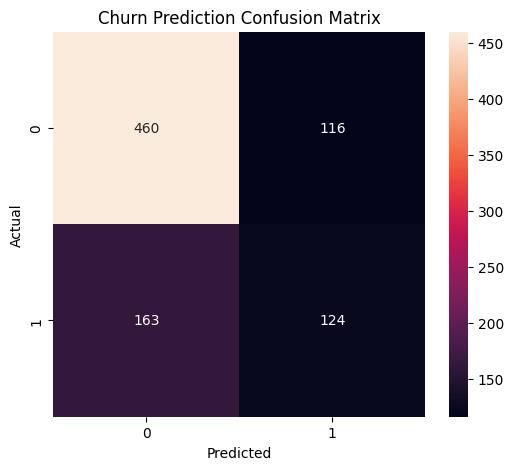

In [86]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    preds
)

print("\nConfusion Matrix\n")

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d"
)

plt.title(
    "Churn Prediction Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


In [87]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
3,FrequencyScore,0.437111
0,Frequency,0.341578
4,MonetaryScore,0.087580
1,Monetary,0.070395
2,AverageOrderValue,0.063336


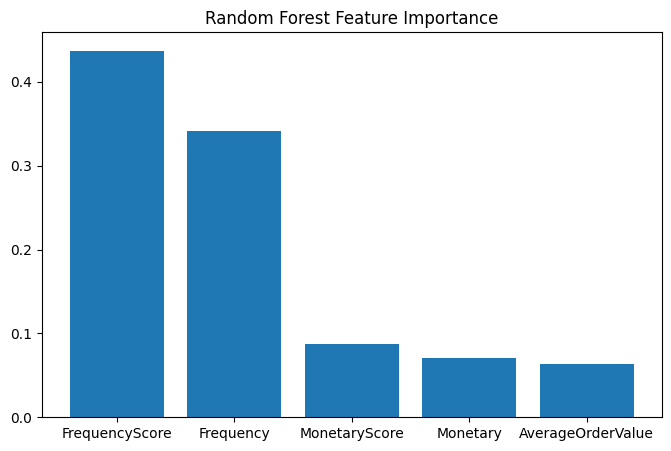

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    importance_df["Feature"],

    importance_df["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [89]:
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest",

        "XGBoost"
    ],

    "AUC": [

        logistic_auc,

        rf_auc,

        xgb_auc
    ]
})

results.sort_values(
    "AUC",
    ascending=False
)

,Model,AUC
0,Logistic Regression,0.737348
1,Random Forest,0.719086
2,XGBoost,0.705977


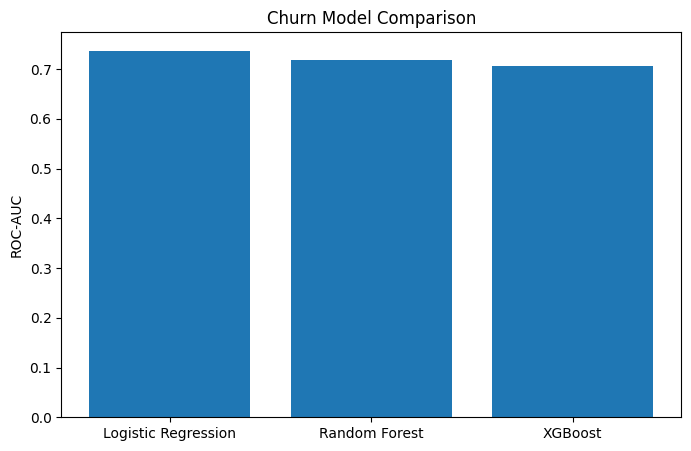

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    results["Model"],

    results["AUC"]
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "Churn Model Comparison"
)

plt.show()

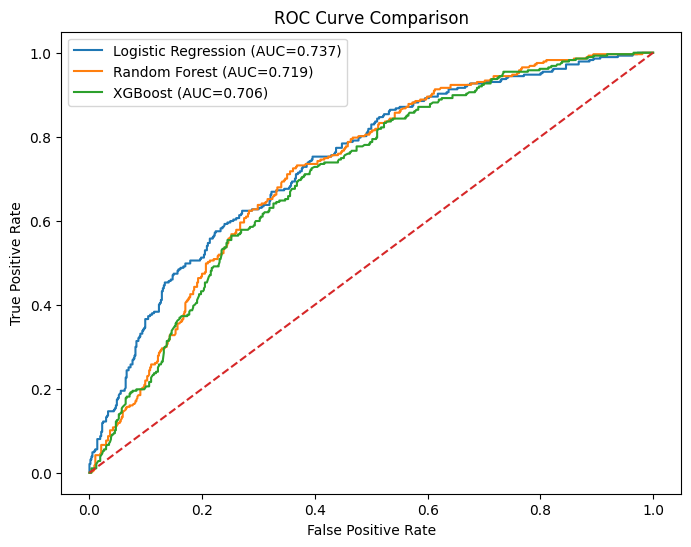

In [92]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

plt.figure(figsize=(8,6))

# Logistic

fpr, tpr, _ = roc_curve(
    y_test,
    logistic_probs
)

plt.plot(

    fpr,

    tpr,

    label=f"Logistic Regression (AUC={roc_auc_score(y_test, logistic_probs):.3f})"
)

# Random Forest

fpr, tpr, _ = roc_curve(
    y_test,
    rf_probs
)

plt.plot(

    fpr,

    tpr,

    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_probs):.3f})"
)

# XGBoost

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_probs
)

plt.plot(

    fpr,

    tpr,

    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.3f})"
)

# Random Baseline

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

In [127]:
joblib.dump(

    model,

    r"C:\Users\91991\Desktop\internships\AMDOX\models\churn\logistic_regression_churn.pkl"
)

print(
    "\nChurn model saved successfully"
)


Churn model saved successfully


In [130]:
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest",

        "XGBoost"
    ],

    "ROC_AUC": [

        0.737,

        0.719,

        0.706
    ]
})

results.to_csv(

    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\churn_model_results.csv",

    index=False
)

print(
    "\nresults saved successfully"
)


results saved successfully
